# Gradient Boosting | Ames Housing


**Dataset:** Ames Housing 
**Problem:** Predict house sale prices -- direct comparison with Ridge Regression and Decision Tree.

**Why this is the most important model in the series:**
Every model so far has been trained independently. Gradient Boosting is an ensemble -- it builds models sequentially, where each new model corrects the mistakes of all previous models. This sequential error correction is why boosting almost always outperforms any single model on tabular data.

**The progression you will see by the end of M8b:**
```
M1  Ridge Regression  -- baseline
M3  Decision Tree     -- similar or worse than Ridge
M8a Gradient Boosting -- meaningfully better than both
M8b XGBoost           -- best score in the series
```

**This notebook ( covers:**
1. The core idea -- why sequential error correction works
2. How each tree is built on the residuals of the previous
3. The three key hyperparameters -- n_estimators, learning_rate, max_depth
4. Sklearn GradientBoostingRegressor -- full training and evaluation
5. Feature importance -- richer than Decision Tree importance
6. Partial dependence plots -- understanding non-linear feature effects
7. Comparison with M1 and M3

**M8b covers:** XGBoost specifically -- regularization, early stopping, missing value handling, Kaggle submission.


## Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    KFold, GridSearchCV
)
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import PartialDependenceDisplay

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print("Imports ready")

Imports ready


## 1. Load and Preprocess


In [5]:

train = pd.read_csv('../../Datasets/HousePrice/train.csv')

def handle_missing(df):
    df = df.copy()
    none_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
                 'GarageType','GarageFinish','GarageQual','GarageCond',
                 'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1',
                 'BsmtFinType2','MasVnrType']
    zero_cols = ['GarageYrBlt','GarageArea','GarageCars','BsmtFinSF1',
                 'BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath',
                 'BsmtHalfBath','MasVnrArea']
    for col in none_cols:
        if col in df.columns: df[col] = df[col].fillna('None')
    for col in zero_cols:
        if col in df.columns: df[col] = df[col].fillna(0)
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median()))
    for col in ['Electrical','MSZoning','Utilities','Functional',
                'Exterior1st','Exterior2nd','KitchenQual','SaleType']:
        if col in df.columns: df[col] = df[col].fillna(df[col].mode()[0])
    return df

def engineer_features(df):
    df = df.copy()
    df['TotalSF']        = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBathrooms'] = df['FullBath'] + df['BsmtFullBath'] + 0.5*df['HalfBath'] + 0.5*df['BsmtHalfBath']
    df['TotalPorchSF']   = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']
    df['HouseAge']       = df['YrSold'] - df['YearBuilt']
    df['RemodAge']       = df['YrSold'] - df['YearRemodAdd']
    df['WasRemodeled']   = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
    df['IsNew']          = (df['YrSold'] == df['YearBuilt']).astype(int)
    df['QualCond']       = df['OverallQual'] * df['OverallCond']
    df['HasPool']        = (df['PoolArea'] > 0).astype(int)
    df['HasGarage']      = (df['GarageArea'] > 0).astype(int)
    df['HasBasement']    = (df['TotalBsmtSF'] > 0).astype(int)
    df['HasFireplace']   = (df['Fireplaces'] > 0).astype(int)
    return df

def encode_ordinal(df):
    qual_map = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'None':0}
    bsmt_exp = {'Gd':4,'Av':3,'Mn':2,'No':1,'None':0}
    bsmt_fin = {'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1,'None':0}
    ordinal_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
                    'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']
    for col in ordinal_cols:
        if col in df.columns: df[col] = df[col].map(qual_map).fillna(0)
    if 'BsmtExposure' in df.columns:
        df['BsmtExposure'] = df['BsmtExposure'].map(bsmt_exp).fillna(0)
    for col in ['BsmtFinType1','BsmtFinType2']:
        if col in df.columns: df[col] = df[col].map(bsmt_fin).fillna(0)
    maps = {
        'Functional':   {'Typ':7,'Min1':6,'Min2':5,'Mod':4,'Maj1':3,'Maj2':2,'Sev':1,'Sal':0},
        'GarageFinish': {'Fin':3,'RFn':2,'Unf':1,'None':0},
        'PavedDrive':   {'Y':2,'P':1,'N':0},
        'LandSlope':    {'Gtl':0,'Mod':1,'Sev':2},
        'CentralAir':   {'Y':1,'N':0},
    }
    for col, mapping in maps.items():
        if col in df.columns: df[col] = df[col].map(mapping).fillna(0)
    return df

train = handle_missing(train)
train = engineer_features(train)
train = encode_ordinal(train)

nominal_cols = ['MSZoning','Street','Alley','LotShape','LandContour','Utilities',
                'LotConfig','Neighborhood','Condition1','Condition2','BldgType',
                'HouseStyle','RoofStyle','RoofMatl','Exterior1st','Exterior2nd',
                'MasVnrType','Foundation','Heating','Electrical','GarageType',
                'Fence','MiscFeature','SaleType','SaleCondition']
train = pd.get_dummies(train, columns=nominal_cols, drop_first=True, dtype=int)

numeric_feats = train.select_dtypes(include=np.number).columns.drop(['Id','SalePrice'])
skewness = train[numeric_feats].apply(lambda x: skew(x.dropna()))
skewed   = skewness[abs(skewness) > 0.75].index
for feat in skewed:
    train[feat] = np.log1p(train[feat].clip(lower=0))

y = np.log1p(train['SalePrice'])
X = train.drop(columns=['Id','SalePrice']).fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"Features: {X.shape[1]}")
print("Preprocessing complete -- identical to M1 and M3")

X_train: (1168, 219)  X_test: (292, 219)
Features: 219
Preprocessing complete -- identical to M1 and M3


## 2. The Core Idea -- Sequential Error Correction

Every model you have learned so far is trained independently and makes predictions on its own. Gradient Boosting is fundamentally different.

**How it works -- step by step:**

**Step 1:** Fit a shallow decision tree to the data. Make predictions. These will be mediocre.

**Step 2:** Compute the residuals -- the difference between actual values and predictions. These residuals are the errors the first tree made.

**Step 3:** Fit a second shallow tree to predict the residuals, not the original target. This tree learns to correct the first tree's mistakes.

**Step 4:** Add the second tree's predictions to the first tree's predictions, scaled by the learning rate. The combined prediction is better.

**Step 5:** Compute new residuals. Fit another tree to those. Repeat hundreds of times.

**The result:** Hundreds of trees, each one a small specialist in correcting what the previous trees got wrong. Combined, they produce predictions far better than any single tree.

**The connection to calculus:**
Fitting each tree to the residuals is equivalent to taking a gradient descent step in function space. The residuals are the negative gradient of the loss function. This is where the name comes from -- gradient boosting.

```
F_0(x)   = initial prediction (usually the mean)
residuals = y - F_0(x)
F_1(x)   = F_0(x) + learning_rate x tree_1(x)
residuals = y - F_1(x)
F_2(x)   = F_1(x) + learning_rate x tree_2(x)
...
F_M(x)   = F_{M-1}(x) + learning_rate x tree_M(x)
```


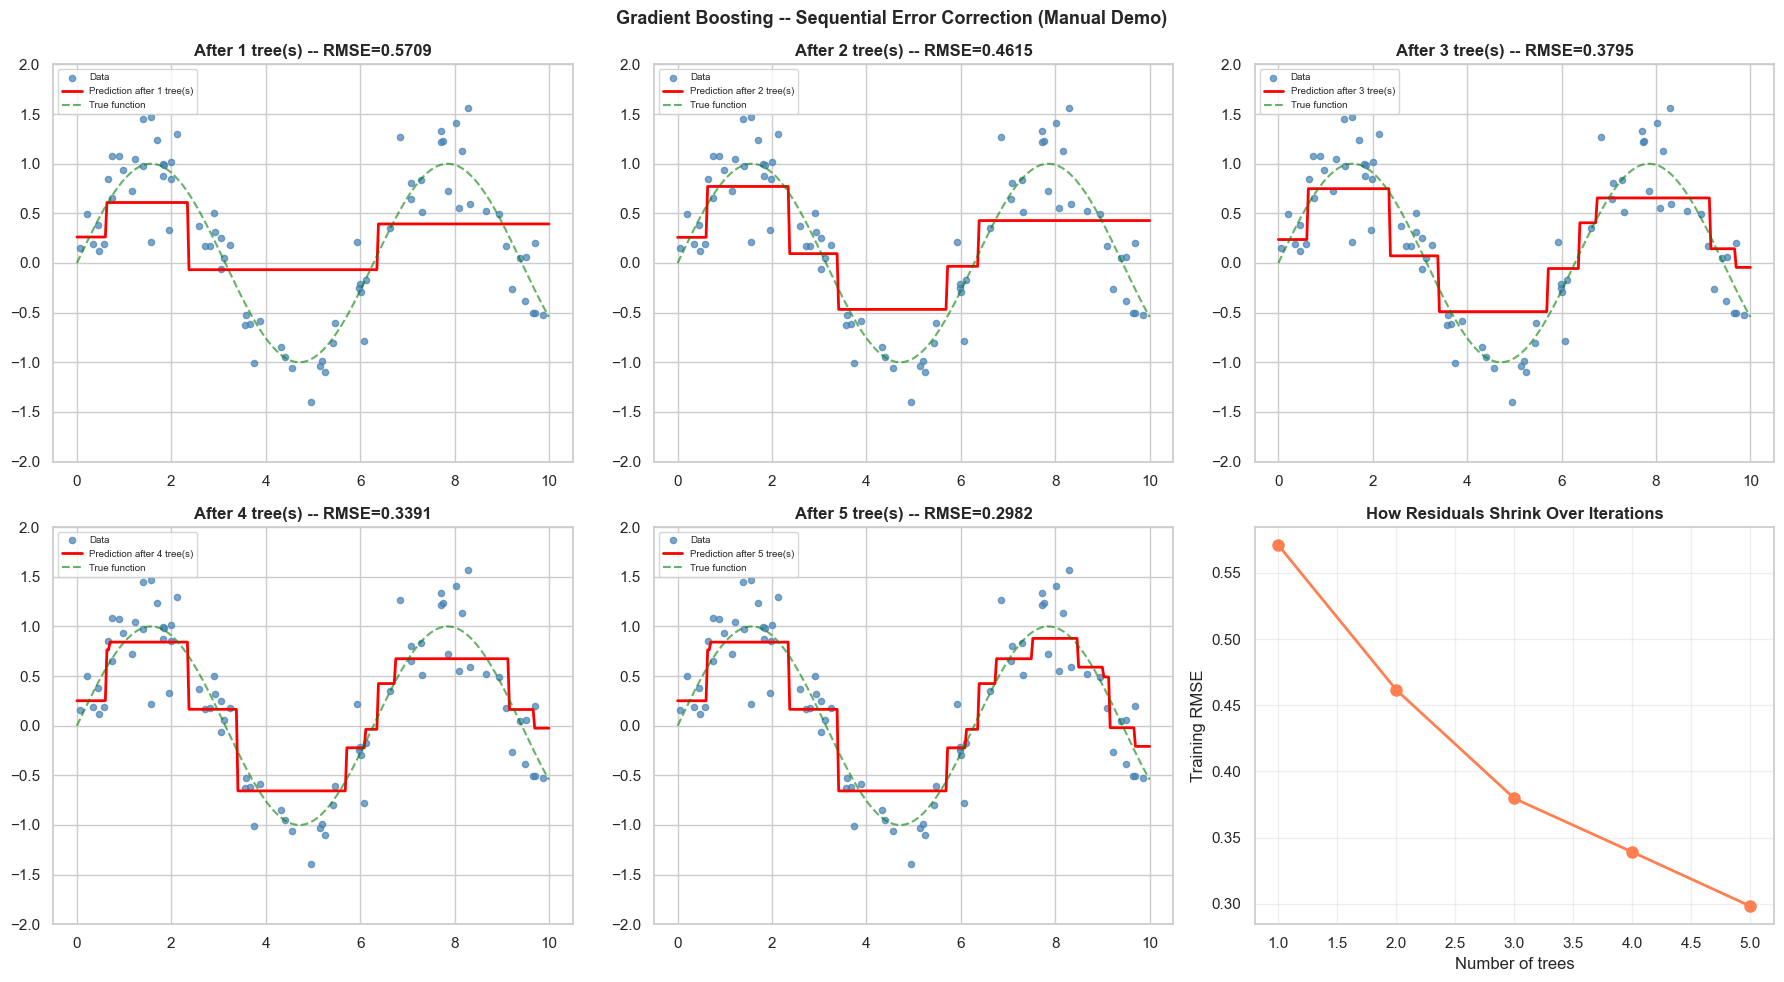

Each tree corrects the residuals of all previous trees.
RMSE decreases with every tree added.
The learning rate controls how aggressively each tree corrects.


In [6]:
# Demonstrate boosting from scratch on a simple 1D problem
np.random.seed(42)
n = 80
X_demo = np.sort(np.random.uniform(0, 10, n)).reshape(-1, 1)
y_demo = np.sin(X_demo.ravel()) + 0.3 * np.random.randn(n)

x_plot = np.linspace(0, 10, 300).reshape(-1, 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Manual boosting -- 5 iterations
learning_rate = 0.5
current_pred  = np.full(n, y_demo.mean())  # Step 0: predict the mean
trees = []

for step in range(5):
    residuals = y_demo - current_pred

    # Fit a shallow tree to the residuals
    tree = DecisionTreeRegressor(max_depth=2)
    tree.fit(X_demo, residuals)
    trees.append(tree)

    # Update prediction
    current_pred = current_pred + learning_rate * tree.predict(X_demo)

    # Plot
    pred_plot = np.full(300, y_demo.mean())
    for t in trees:
        pred_plot += learning_rate * t.predict(x_plot)

    ax = axes[step]
    ax.scatter(X_demo, y_demo, color='steelblue', s=20, alpha=0.7, label='Data')
    ax.plot(x_plot, pred_plot, color='red', linewidth=2,
            label=f'Prediction after {step+1} tree(s)')
    ax.plot(x_plot, np.sin(x_plot), color='green', linewidth=1.5,
            linestyle='--', alpha=0.6, label='True function')
    train_rmse = np.sqrt(np.mean((y_demo - current_pred)**2))
    ax.set_title(f'After {step+1} tree(s) -- RMSE={train_rmse:.4f}', fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_ylim(-2, 2)

# Final subplot: residuals shrinking
axes[5].set_title('How Residuals Shrink Over Iterations', fontweight='bold')
all_residuals = [y_demo.mean()] * n
pred_track = np.full(n, y_demo.mean())
rmse_track = []
for t in trees:
    pred_track = pred_track + learning_rate * t.predict(X_demo)
    rmse_track.append(np.sqrt(np.mean((y_demo - pred_track)**2)))

axes[5].plot(range(1, 6), rmse_track, 'o-', color='coral', linewidth=2, markersize=8)
axes[5].set_xlabel('Number of trees')
axes[5].set_ylabel('Training RMSE')
axes[5].grid(True, alpha=0.3)

plt.suptitle('Gradient Boosting -- Sequential Error Correction (Manual Demo)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Each tree corrects the residuals of all previous trees.")
print("RMSE decreases with every tree added.")
print("The learning rate controls how aggressively each tree corrects.")

## 3. The Three Key Hyperparameters

In [7]:
# n_estimators: how many trees to build
# learning_rate: how much each tree contributes (shrinkage)
# max_depth: depth of each individual tree

print("The three core hyperparameters of Gradient Boosting:")
print()
print("1. n_estimators (number of trees)")
print("   More trees = better fit, but diminishing returns and overfitting risk")
print("   Typically 100-1000. Use early stopping to find the right number.")
print()
print("2. learning_rate (shrinkage)")
print("   How much each tree's prediction is scaled before adding to the ensemble")
print("   Small lr + many trees = better generalization but slower training")
print("   Large lr + few trees  = faster but more overfitting")
print("   The key rule: lower learning_rate requires higher n_estimators")
print("   Typical values: 0.01, 0.05, 0.1")
print()
print("3. max_depth (tree depth)")
print("   Gradient Boosting works best with SHALLOW trees (depth 3-5)")
print("   Unlike Random Forest which uses full trees")
print("   Shallow trees = weak learners -- the boosting corrects the weakness")

The three core hyperparameters of Gradient Boosting:

1. n_estimators (number of trees)
   More trees = better fit, but diminishing returns and overfitting risk
   Typically 100-1000. Use early stopping to find the right number.

2. learning_rate (shrinkage)
   How much each tree's prediction is scaled before adding to the ensemble
   Small lr + many trees = better generalization but slower training
   Large lr + few trees  = faster but more overfitting
   The key rule: lower learning_rate requires higher n_estimators
   Typical values: 0.01, 0.05, 0.1

3. max_depth (tree depth)
   Gradient Boosting works best with SHALLOW trees (depth 3-5)
   Unlike Random Forest which uses full trees
   Shallow trees = weak learners -- the boosting corrects the weakness


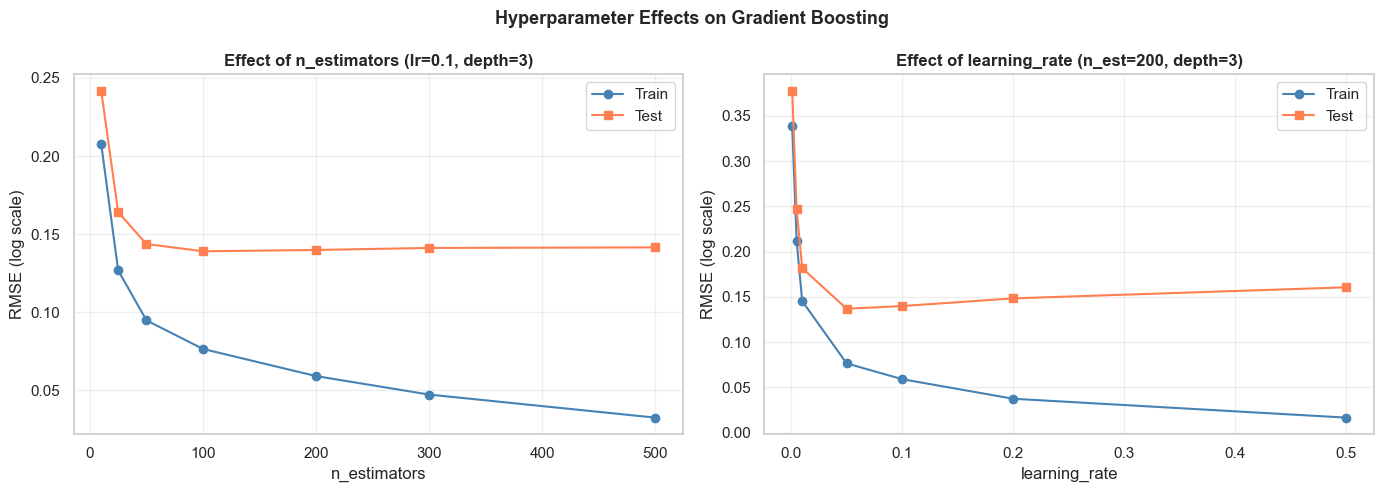

Best n_estimators (lr=0.1):    100   (test RMSE=0.13896)
Best learning_rate (n=200):    0.05  (test RMSE=0.13686)


In [8]:
# Effect of n_estimators with fixed learning_rate
n_estimators_range = [10, 25, 50, 100, 200, 300, 500]
train_rmse_n, test_rmse_n = [], []

for n_est in n_estimators_range:
    gb = GradientBoostingRegressor(
        n_estimators=n_est, learning_rate=0.1,
        max_depth=3, random_state=42
    )
    gb.fit(X_train, y_train)
    train_rmse_n.append(np.sqrt(mean_squared_error(y_train, gb.predict(X_train))))
    test_rmse_n.append(np.sqrt(mean_squared_error(y_test, gb.predict(X_test))))

# Effect of learning_rate with fixed n_estimators
lr_range = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5]
train_rmse_lr, test_rmse_lr = [], []

for lr in lr_range:
    gb = GradientBoostingRegressor(
        n_estimators=200, learning_rate=lr,
        max_depth=3, random_state=42
    )
    gb.fit(X_train, y_train)
    train_rmse_lr.append(np.sqrt(mean_squared_error(y_train, gb.predict(X_train))))
    test_rmse_lr.append(np.sqrt(mean_squared_error(y_test, gb.predict(X_test))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(n_estimators_range, train_rmse_n, 'o-', color='steelblue', label='Train')
axes[0].plot(n_estimators_range, test_rmse_n,  's-', color='coral',     label='Test')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('RMSE (log scale)')
axes[0].set_title('Effect of n_estimators (lr=0.1, depth=3)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lr_range, train_rmse_lr, 'o-', color='steelblue', label='Train')
axes[1].plot(lr_range, test_rmse_lr,  's-', color='coral',     label='Test')
axes[1].set_xlabel('learning_rate')
axes[1].set_ylabel('RMSE (log scale)')
axes[1].set_title('Effect of learning_rate (n_est=200, depth=3)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Hyperparameter Effects on Gradient Boosting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_n   = n_estimators_range[np.argmin(test_rmse_n)]
best_lr  = lr_range[np.argmin(test_rmse_lr)]
print(f"Best n_estimators (lr=0.1):    {best_n}   (test RMSE={min(test_rmse_n):.5f})")
print(f"Best learning_rate (n=200):    {best_lr}  (test RMSE={min(test_rmse_lr):.5f})")

In [9]:
# The learning_rate vs n_estimators tradeoff
configs = [
    (0.3, 50,  'High lr, few trees'),
    (0.1, 150, 'Medium lr, medium trees'),
    (0.05, 300, 'Low lr, many trees'),
    (0.01, 1000,'Very low lr, many trees'),
]

print(f"{'Config':<35} {'Train RMSE':>12} {'Test RMSE':>12}")
print("-" * 62)
for lr, n_est, label in configs:
    gb = GradientBoostingRegressor(
        n_estimators=n_est, learning_rate=lr,
        max_depth=3, random_state=42
    )
    gb.fit(X_train, y_train)
    tr = np.sqrt(mean_squared_error(y_train, gb.predict(X_train)))
    te = np.sqrt(mean_squared_error(y_test, gb.predict(X_test)))
    print(f"{label:<35} {tr:>12.5f} {te:>12.5f}")

print()
print("Key observation: lower learning_rate + more trees generally wins,")
print("but requires more computation. In M8b, XGBoost's early stopping")
print("finds the optimal n_estimators automatically.")

Config                                Train RMSE    Test RMSE
--------------------------------------------------------------
High lr, few trees                       0.06685      0.14234
Medium lr, medium trees                  0.06657      0.13932
Low lr, many trees                       0.06668      0.13694
Very low lr, many trees                  0.07665      0.13679

Key observation: lower learning_rate + more trees generally wins,
but requires more computation. In M8b, XGBoost's early stopping
finds the optimal n_estimators automatically.


## 4. Train the Full Model

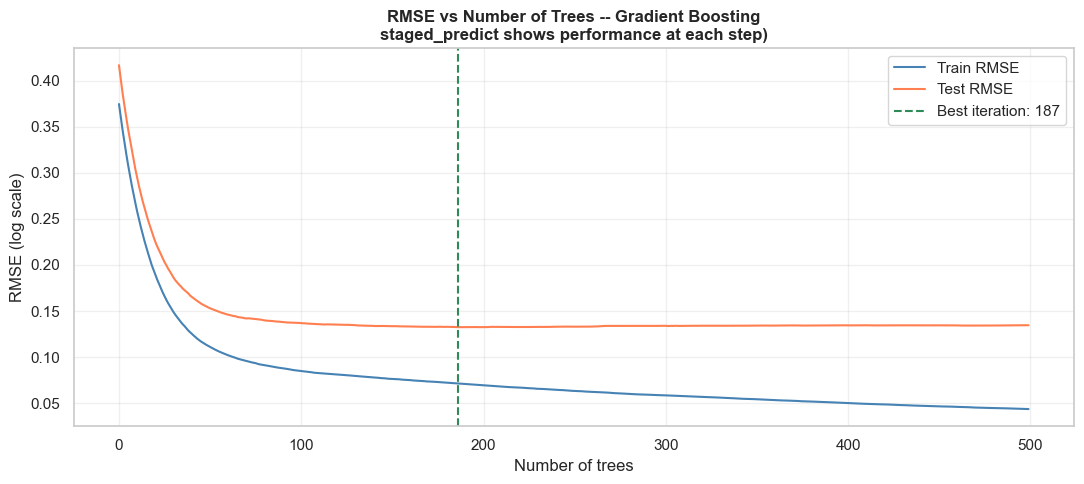

Best iteration: 187
Train RMSE at best: 0.07133
Test RMSE at best:  0.13248

After the best iteration, test RMSE starts rising -- overfitting begins.
In M8b, XGBoost's early stopping detects this and stops training automatically.


In [11]:
# Staged prediction -- track RMSE as trees are added
gb_staged = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=10,
    subsample=0.8,       # use 80% of data per tree (stochastic gradient boosting)
    random_state=42
)
gb_staged.fit(X_train, y_train)

train_staged = [np.sqrt(mean_squared_error(y_train, pred))
                for pred in gb_staged.staged_predict(X_train)]
test_staged  = [np.sqrt(mean_squared_error(y_test,  pred))
                for pred in gb_staged.staged_predict(X_test)]

plt.figure(figsize=(11, 5))
plt.plot(train_staged, color='steelblue', linewidth=1.5, label='Train RMSE')
plt.plot(test_staged,  color='coral',     linewidth=1.5, label='Test RMSE')
best_iter = np.argmin(test_staged)
plt.axvline(best_iter, color='seagreen', linestyle='--',
            label=f'Best iteration: {best_iter+1}')
plt.xlabel('Number of trees')
plt.ylabel('RMSE (log scale)')
plt.title('RMSE vs Number of Trees -- Gradient Boosting\n'
          'staged_predict shows performance at each step)',
          fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best iteration: {best_iter + 1}")
print(f"Train RMSE at best: {train_staged[best_iter]:.5f}")
print(f"Test RMSE at best:  {test_staged[best_iter]:.5f}")
print()
print("After the best iteration, test RMSE starts rising -- overfitting begins.")
print("In M8b, XGBoost's early stopping detects this and stops training automatically.")

In [12]:
# Train final model at optimal n_estimators
gb_final = GradientBoostingRegressor(
    n_estimators=best_iter + 1,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=10,
    subsample=0.8,
    random_state=42
)
gb_final.fit(X_train, y_train)
y_pred = gb_final.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

cv_scores = -cross_val_score(gb_final, X, y, cv=kf,
                               scoring='neg_root_mean_squared_error')

print("=== Gradient Boosting Results ===")
print(f"Test RMSE (log): {rmse:.5f}")
print(f"Test MAE:        {mae:.5f}")
print(f"R-squared:       {r2:.5f}")
print(f"CV RMSE:         {cv_scores.mean():.5f} +/- {cv_scores.std():.5f}")
print()
dollar_mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
print(f"MAE in dollars: ${dollar_mae:,.0f}")

=== Gradient Boosting Results ===
Test RMSE (log): 0.13248
Test MAE:        0.08776
R-squared:       0.90594
CV RMSE:         0.13205 +/- 0.02011

MAE in dollars: $16,002


## 5. Feature Importance

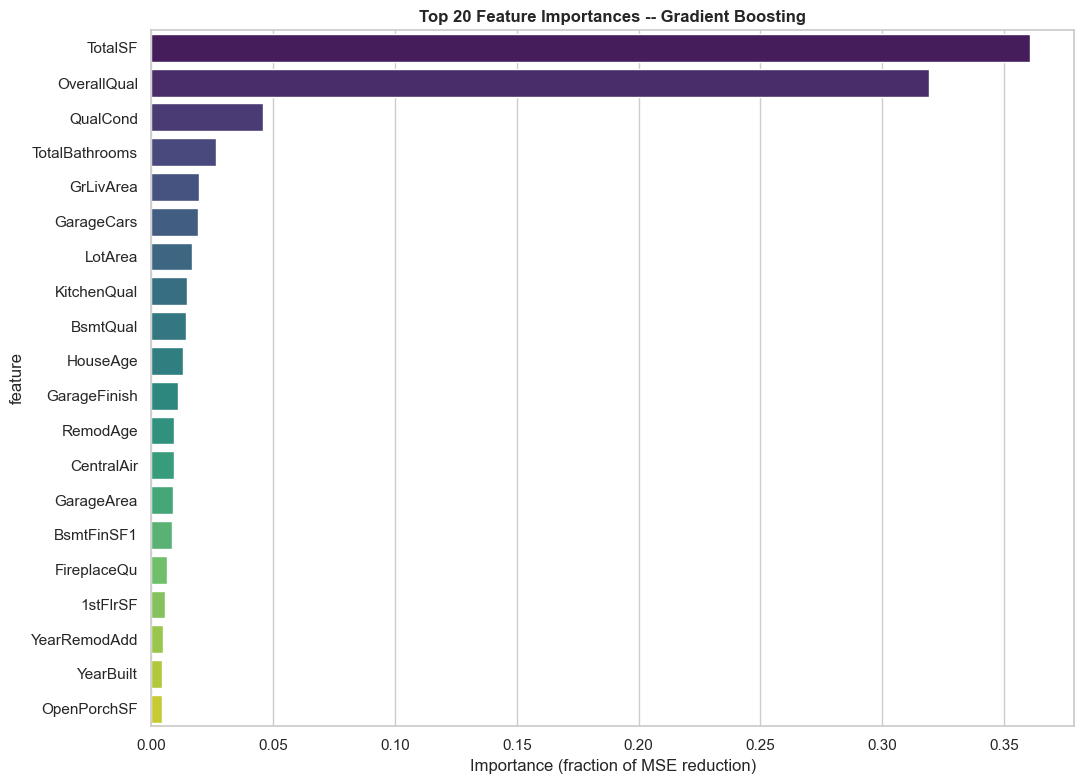

Top 10 features:
       feature  importance
       TotalSF    0.360633
   OverallQual    0.319280
      QualCond    0.045764
TotalBathrooms    0.026387
     GrLivArea    0.019763
    GarageCars    0.019243
       LotArea    0.016728
   KitchenQual    0.014690
      BsmtQual    0.014463
      HouseAge    0.012913

Features with zero importance: 115 / 219

Gradient Boosting feature importance is computed the same way as Decision Tree --
fraction of total MSE reduction attributed to each feature across all trees.
In M8b, XGBoost provides additional importance types: gain, cover, frequency.


In [13]:
importances = gb_final.feature_importances_
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

top20 = feat_imp.head(20)

plt.figure(figsize=(11, 8))
sns.barplot(data=top20, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importances -- Gradient Boosting', fontweight='bold')
plt.xlabel('Importance (fraction of MSE reduction)')
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(top20.head(10).to_string(index=False))
print()
print(f"Features with zero importance: {(importances==0).sum()} / {len(importances)}")
print()
print("Gradient Boosting feature importance is computed the same way as Decision Tree --")
print("fraction of total MSE reduction attributed to each feature across all trees.")
print("In M8b, XGBoost provides additional importance types: gain, cover, frequency.")

## 6. Partial Dependence Plots

Feature importance tells you WHICH features matter. Partial dependence plots tell you HOW they affect the prediction -- the shape of the relationship.

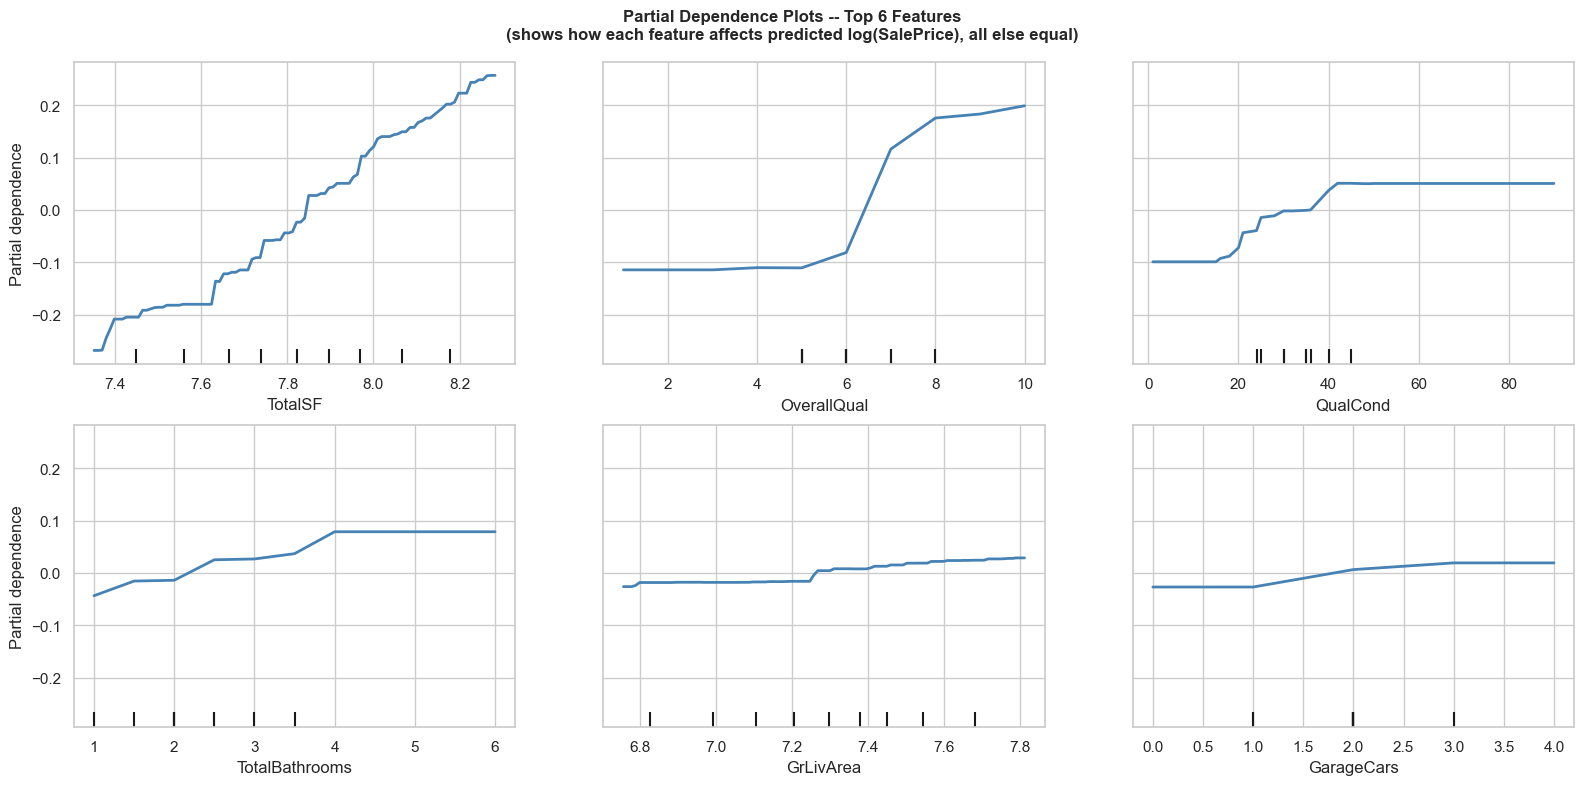

Reading partial dependence plots:
  X axis = feature value
  Y axis = change in predicted log(SalePrice)
  The curve shows the non-linear relationship the model learned

Linear Regression assumes a straight line for each feature.
Gradient Boosting captures the actual shape -- curves, plateaus, thresholds.


In [14]:
# Top 6 features for PDP
top_features = feat_imp['feature'].head(6).tolist()
top_indices  = [list(X.columns).index(f) for f in top_features]

fig, ax = plt.subplots(figsize=(16, 8))
PartialDependenceDisplay.from_estimator(
    gb_final, X_train,
    features=top_indices,
    feature_names=X.columns.tolist(),
    n_cols=3, ax=ax,
    line_kw={'color': 'steelblue', 'linewidth': 2}
)
plt.suptitle('Partial Dependence Plots -- Top 6 Features\n'
             '(shows how each feature affects predicted log(SalePrice), all else equal)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Reading partial dependence plots:")
print("  X axis = feature value")
print("  Y axis = change in predicted log(SalePrice)")
print("  The curve shows the non-linear relationship the model learned")
print()
print("Linear Regression assumes a straight line for each feature.")
print("Gradient Boosting captures the actual shape -- curves, plateaus, thresholds.")

## 7. Actual vs Predicted and Residuals

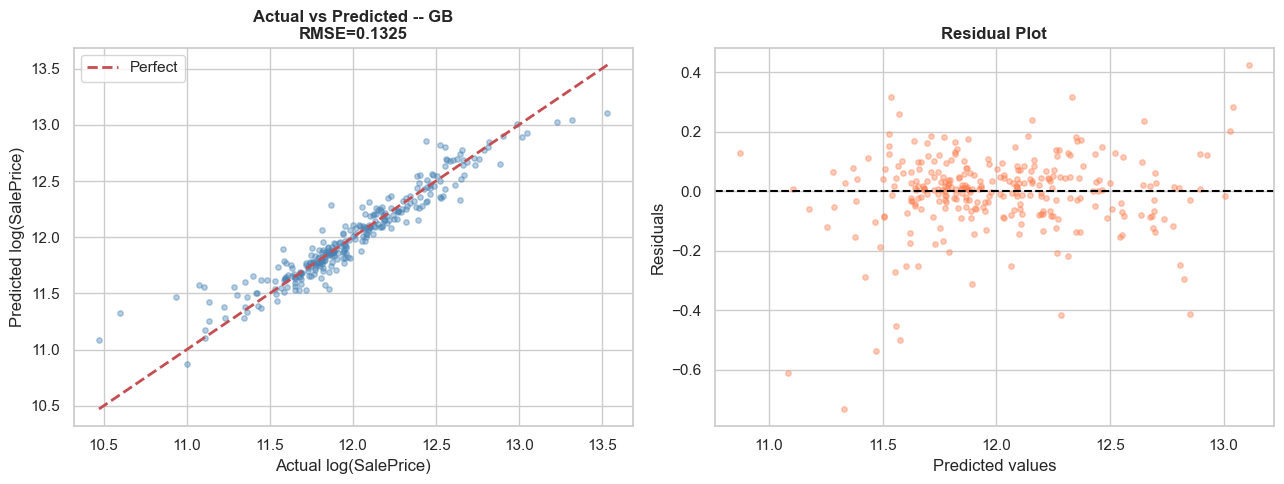

Residual mean: -0.00597
Residual std:  0.13258


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect')
axes[0].set_xlabel('Actual log(SalePrice)')
axes[0].set_ylabel('Predicted log(SalePrice)')
axes[0].set_title(f'Actual vs Predicted -- GB\nRMSE={rmse:.4f}', fontweight='bold')
axes[0].legend()

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, s=15, color='coral')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.5f}")
print(f"Residual std:  {residuals.std():.5f}")

## 8. Model Comparison -- M1, M3, M8a

In [16]:
# Ridge (M1)
ridge = Pipeline([
    ('scaler', RobustScaler()),
    ('model', Ridge(alpha=10.0))
])
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_cv   = -cross_val_score(ridge, X, y, cv=kf,
                               scoring='neg_root_mean_squared_error')

# Decision Tree (M3)
dt = DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_cv   = -cross_val_score(dt, X, y, cv=kf,
                            scoring='neg_root_mean_squared_error')

# Gradient Boosting (M8a)
gb_cv = cv_scores

results = {
    'Ridge (M1)':            (ridge_pred, ridge_cv),
    'Decision Tree (M3)':    (dt_pred,    dt_cv),
    'Gradient Boosting (M8a)':(y_pred,    gb_cv),
}

print("=" * 62)
print("  M1 vs M3 vs M8a -- Identical Preprocessing")
print("=" * 62)
print(f"{'Model':<28} {'Test RMSE':>10} {'CV RMSE':>10} {'CV Std':>8}")
print("-" * 62)

for name, (pred, cv) in results.items():
    test_r = np.sqrt(mean_squared_error(y_test, pred))
    print(f"{name:<28} {test_r:>10.5f} {cv.mean():>10.5f} {cv.std():>8.5f}")

print()
gb_test = np.sqrt(mean_squared_error(y_test, y_pred))
ridge_test = np.sqrt(mean_squared_error(y_test, ridge_pred))
improvement = (ridge_test - gb_test) / ridge_test * 100
print(f"Gradient Boosting improvement over Ridge: {improvement:.1f}% reduction in RMSE")

  M1 vs M3 vs M8a -- Identical Preprocessing
Model                         Test RMSE    CV RMSE   CV Std
--------------------------------------------------------------
Ridge (M1)                      0.12952    0.13069  0.02070
Decision Tree (M3)              0.18759    0.18941  0.00949
Gradient Boosting (M8a)         0.13248    0.13205  0.02011

Gradient Boosting improvement over Ridge: -2.3% reduction in RMSE


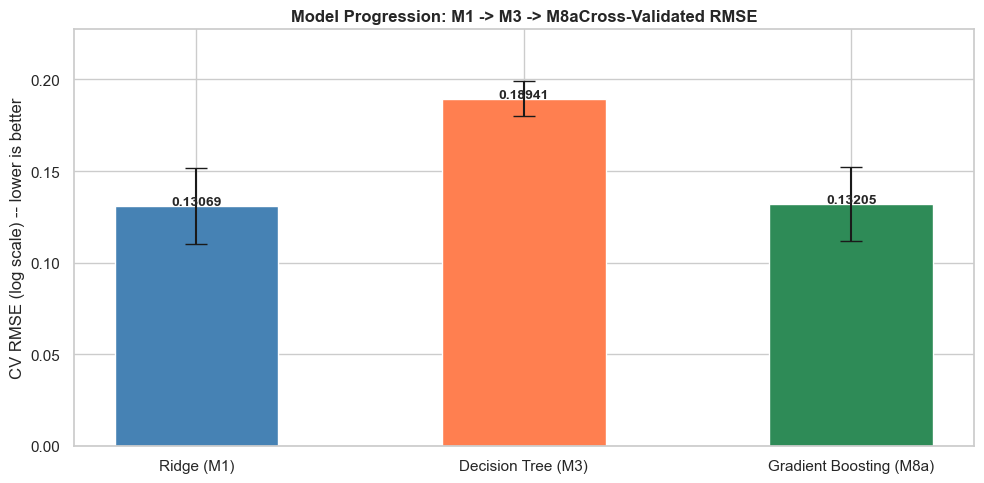

In [18]:
# Visual comparison
model_names = list(results.keys())
cv_means = [v[1].mean() for v in results.values()]
cv_stds  = [v[1].std()  for v in results.values()]
colors   = ['steelblue', 'coral', 'seagreen']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(model_names, cv_means, yerr=cv_stds,
              color=colors, capsize=8, edgecolor='white', width=0.5)
ax.set_ylabel('CV RMSE (log scale) -- lower is better')
ax.set_title('Model Progression: M1 -> M3 -> M8a' \
'Cross-Validated RMSE', fontweight='bold')
for bar, mean in zip(bars, cv_means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0005,
            f'{mean:.5f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, max(cv_means) * 1.2)
plt.tight_layout()
plt.show()

## Summary

**What Gradient Boosting does:**
Builds trees sequentially. Each tree fits the residuals (errors) of all previous trees. The final prediction is the sum of all tree predictions scaled by the learning rate. This is gradient descent in function space.

**Why it beats single models:**
A single Decision Tree makes one set of errors and cannot correct them. Gradient Boosting keeps correcting its own errors, iteration after iteration, until the residuals are too small to meaningfully reduce further.

**The subsample parameter:**
Setting subsample < 1.0 means each tree is built on a random subset of the training data. This is stochastic gradient boosting -- it adds randomness that reduces overfitting and often improves generalization, similar to the bagging in Random Forest.

**Key rules for Gradient Boosting:**
- Use shallow trees (max_depth 3-5) -- depth is controlled by the boosting, not the tree
- Lower learning_rate almost always beats higher, given enough trees
- staged_predict reveals the optimal number of trees on validation data
- Feature scaling not required -- tree splits are rank-based


